# 02 - Carbon-Aware Scheduler

Goal: compare scheduling strategies across multiple real weeks of the HPC trace using synthetic carbon intensity.

Unlike the earlier prototype, this scheduler respects:

- job release time, so a job cannot start before submission;
- job duration over discrete time slots;
- parallel system capacity, modeled through requested processors;
- maximum delay for the carbon-aware policy.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT / 'results' / 'scheduler'
sys.path.insert(0, str(PROJECT / 'src'))

print('Project:', PROJECT)
print('Results:', RESULTS)

Project: C:\Users\morne\Desktop\AI for industry\project_rebuild
Results: C:\Users\morne\Desktop\AI for industry\project_rebuild\results\scheduler


## Result Generation

Run the energy/carbon prediction first, then the scheduler:

```bash
python scripts/01_run_carbon_prediction.py --max-rows 60000
python scripts/02_run_scheduler.py --num-weeks 0 --max-jobs 1200 --split all
```

In [2]:
metrics = pd.read_csv(RESULTS / 'scheduler_metrics.csv')
metrics

,policy,scheduled_jobs,skipped_jobs,total_actual_energy_kwh,total_actual_emissions_kg,total_predicted_emissions_kg,avg_wait_h,median_wait_h,p95_wait_h,avg_slowdown,max_processors_used,emissions_delta_vs_fcfs_kg,emissions_reduction_vs_fcfs_pct,avg_wait_delta_vs_fcfs_h
0,fcfs,12000.0,0.0,84836.381528,27364.660871,19237.746126,0.000000,0.000000,0.000000,1.000000,1452.0,0.000000,0.000000,0.000000
1,random,12000.0,0.0,84836.381528,27078.906180,19012.700449,11.744625,11.750139,22.758444,18.924428,761.0,-285.754691,1.044247,11.744625
2,carbon_aware,12000.0,0.0,84836.381528,25965.451980,18107.174151,12.398186,12.543889,20.146389,20.527510,8175.0,-1399.208890,5.113197,12.398186


In [3]:
weekly = pd.read_csv(RESULTS / 'scheduler_weekly_metrics.csv')
carbon_weekly = weekly[weekly['policy'].eq('carbon_aware')]
summary = {
    'weeks': weekly['week_index'].nunique(),
    'jobs_per_policy': int(metrics.loc[metrics['policy'].eq('carbon_aware'), 'scheduled_jobs'].iloc[0]),
    'carbon_aware_reduction_weighted_pct': metrics.loc[metrics['policy'].eq('carbon_aware'), 'emissions_reduction_vs_fcfs_pct'].iloc[0],
    'carbon_aware_reduction_weekly_mean_pct': carbon_weekly['emissions_reduction_vs_fcfs_pct'].mean(),
    'carbon_aware_reduction_weekly_min_pct': carbon_weekly['emissions_reduction_vs_fcfs_pct'].min(),
    'carbon_aware_reduction_weekly_max_pct': carbon_weekly['emissions_reduction_vs_fcfs_pct'].max(),
}
pd.Series(summary).to_frame('value')

,value
weeks,10.000000
jobs_per_policy,12000.000000
carbon_aware_reduction_weighted_pct,5.113197
carbon_aware_reduction_weekly_mean_pct,7.464613
carbon_aware_reduction_weekly_min_pct,3.067298
carbon_aware_reduction_weekly_max_pct,14.405178


## Compared Policies

- `fcfs`: first-come first-served; each job starts as soon as capacity is available.
- `random`: random feasible delay, useful as a simple baseline.
- `carbon_aware`: for each job, searches within the maximum delay window and selects the feasible start time with the lowest average carbon intensity, using predicted energy.

Hardware note: based on the project notes, Marconi-100 is modeled with 980 nodes and 16 processors per node, for a total of 15,680 processors. The PM100 column `num_nodes_req` is treated as requested processors, not as nodes.

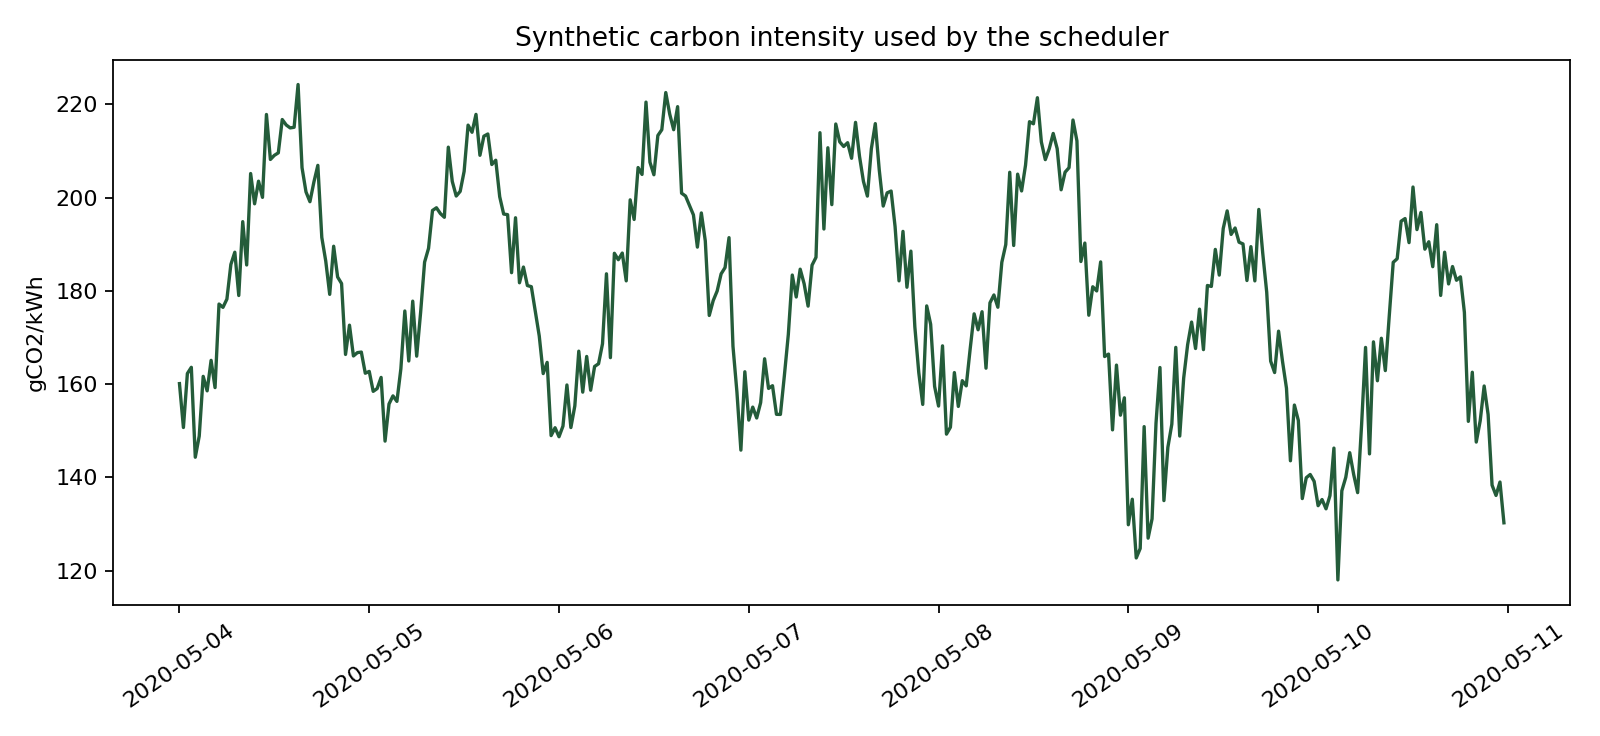

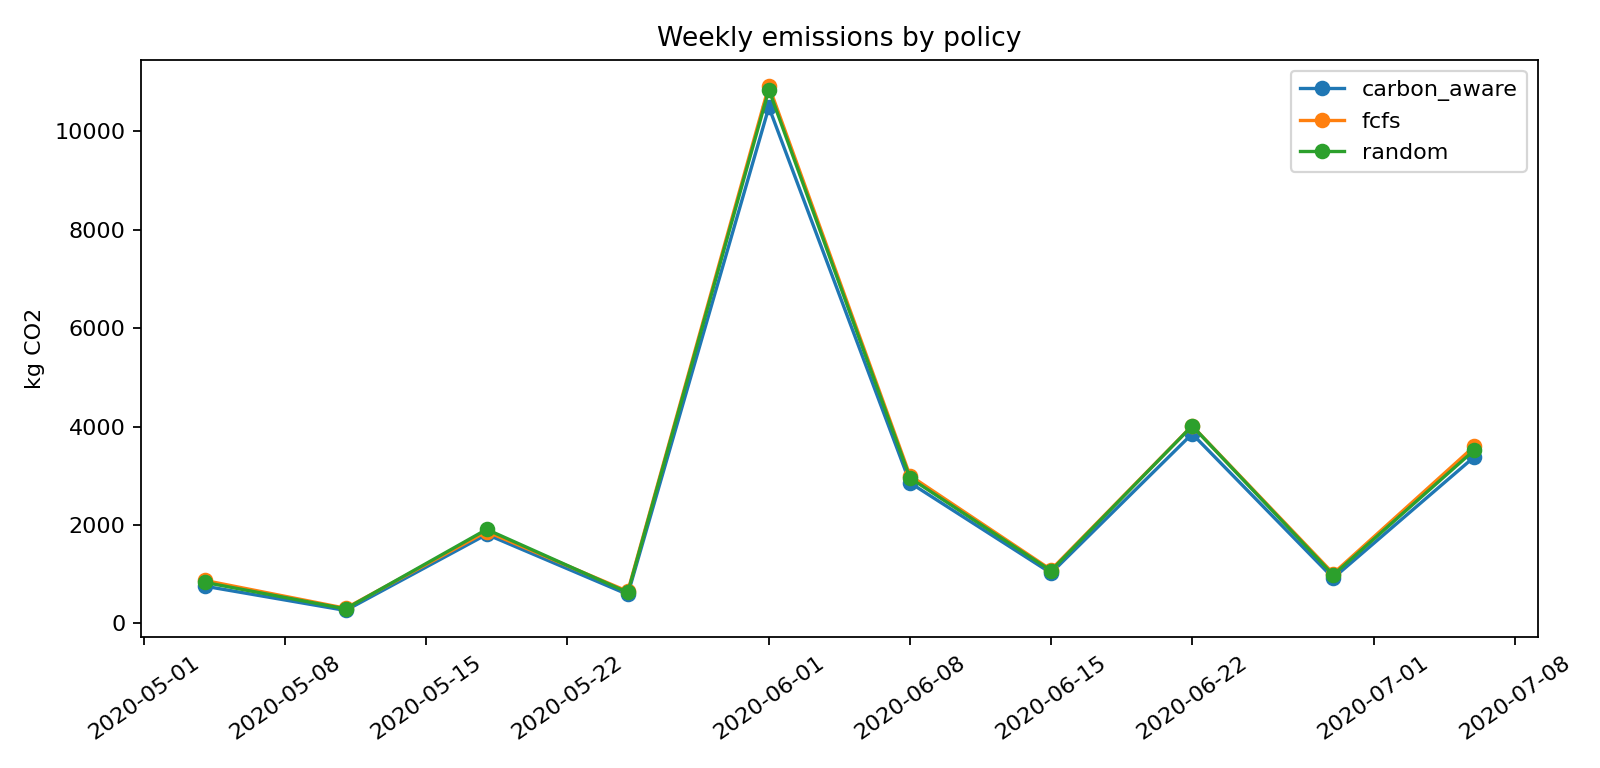

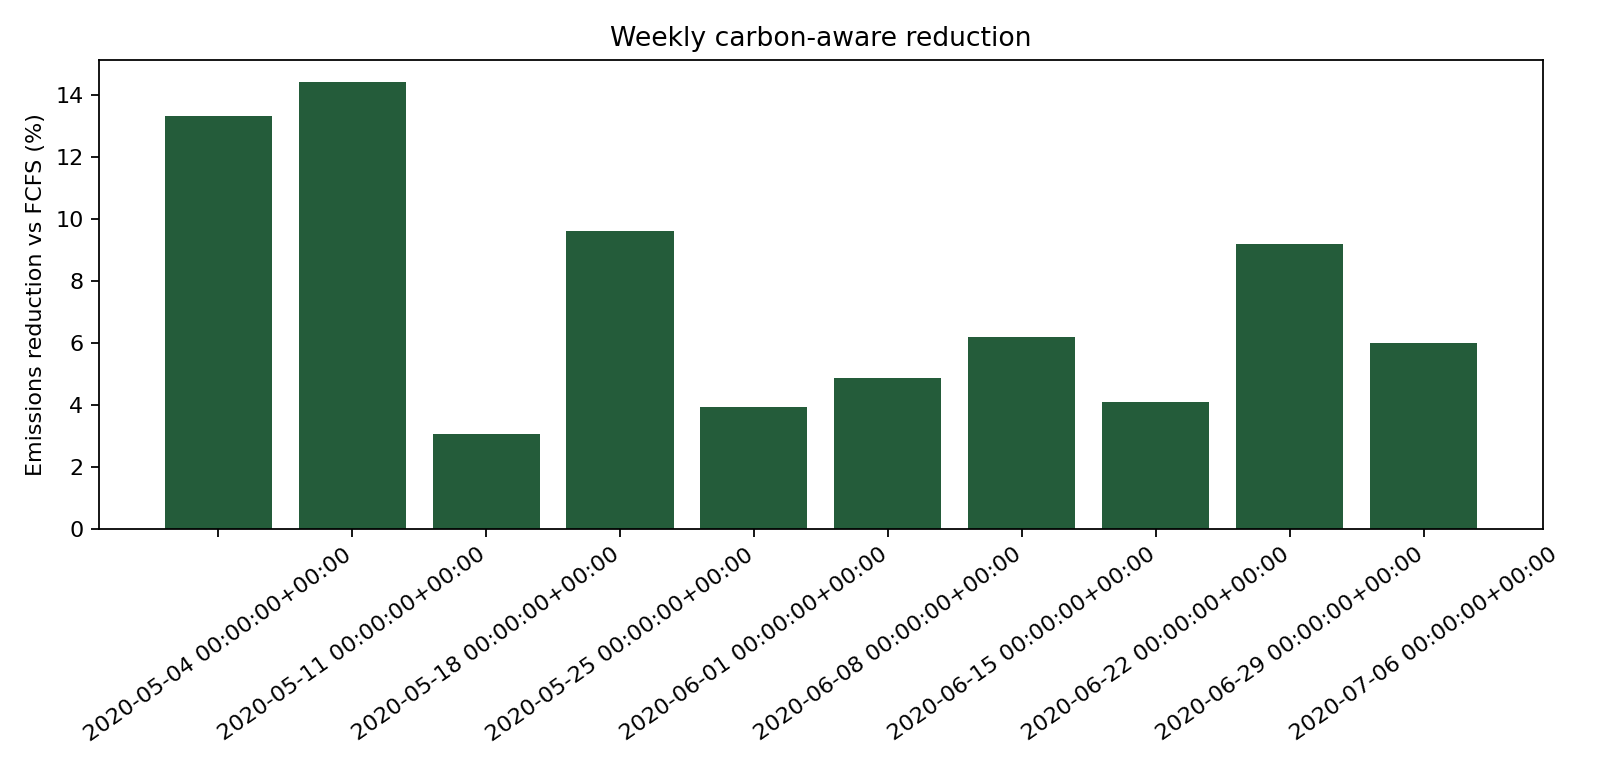

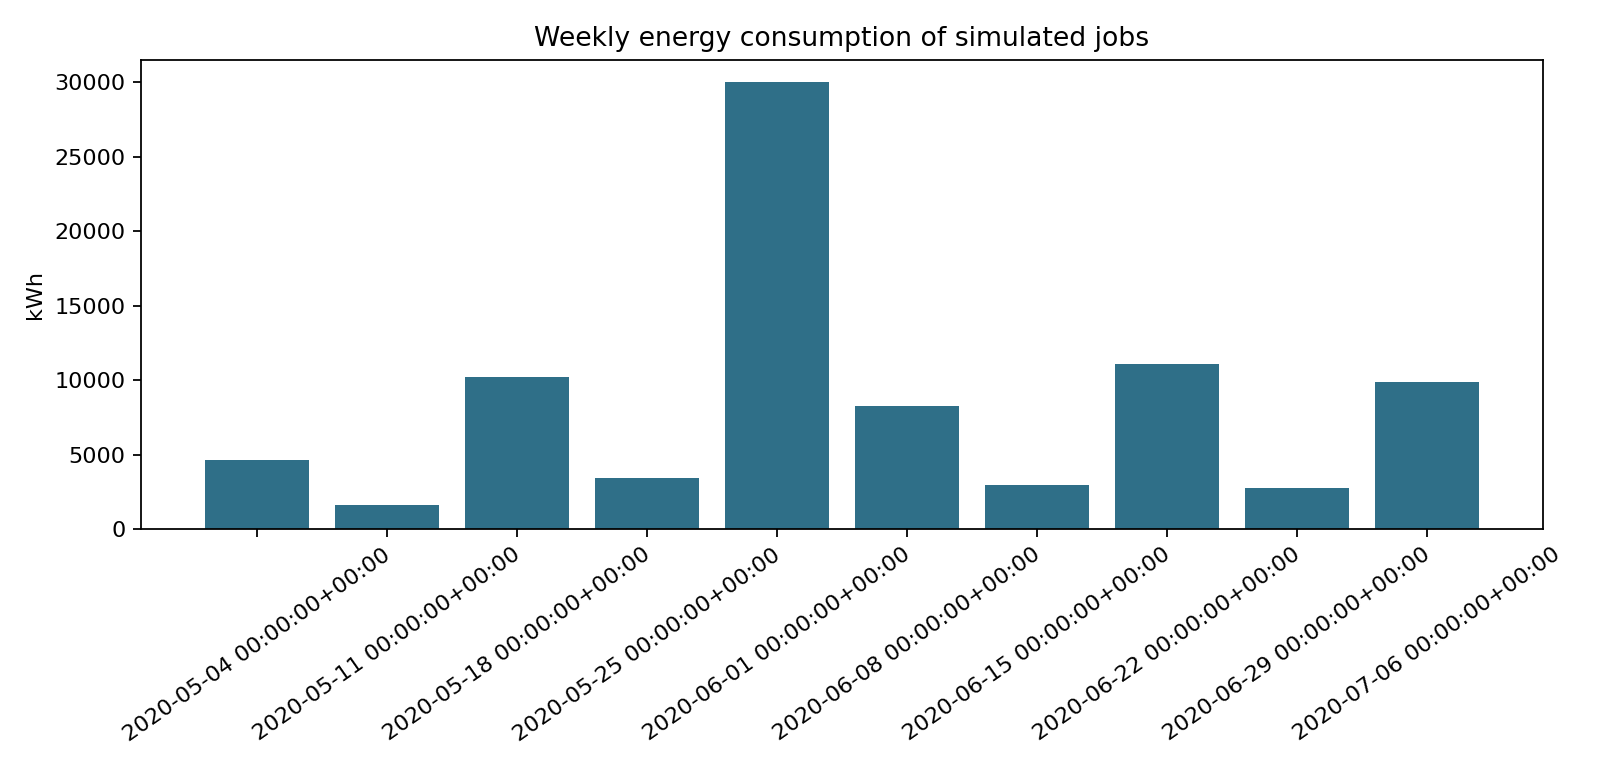

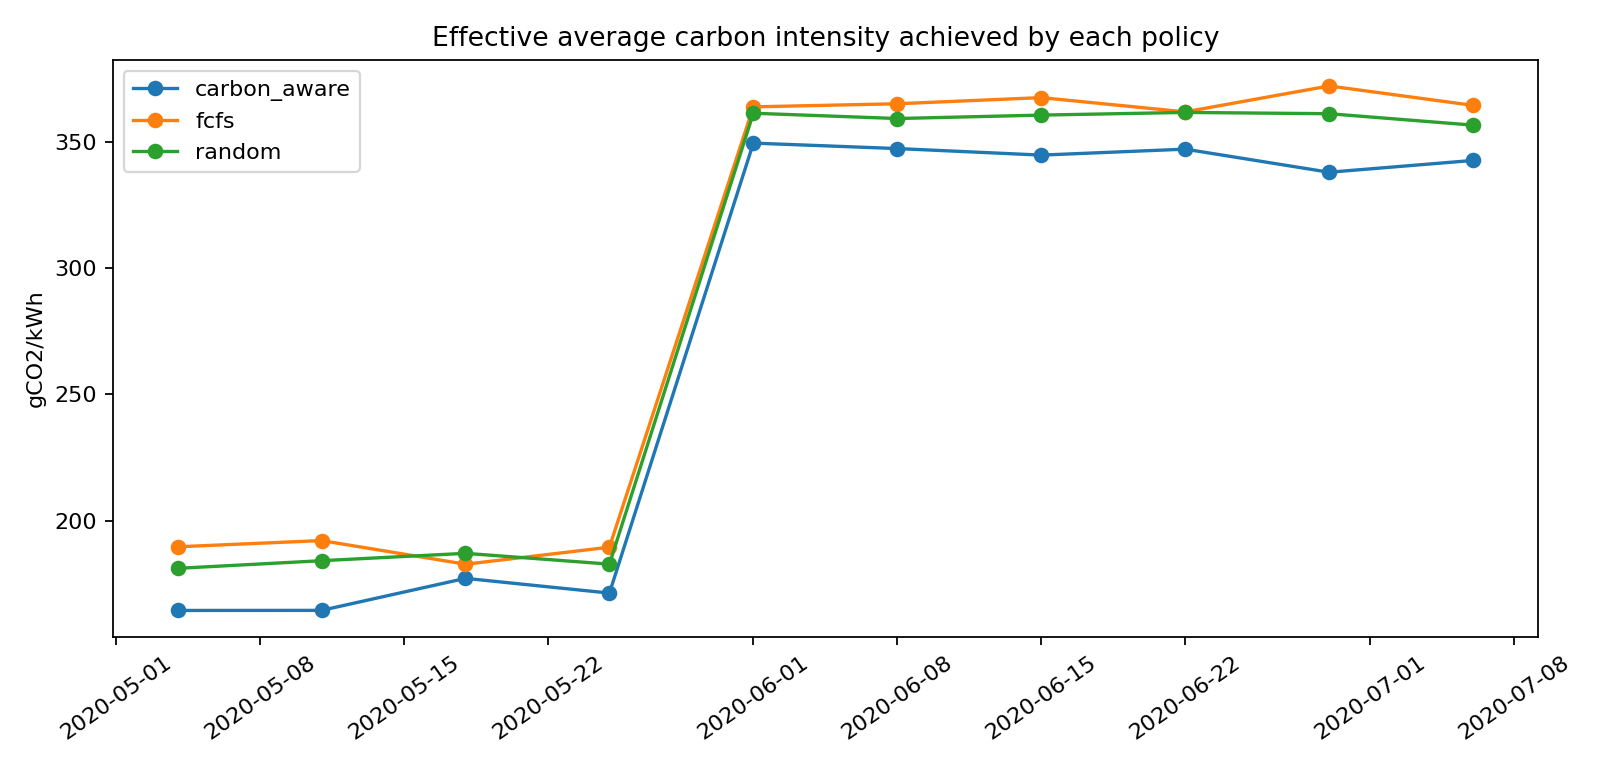

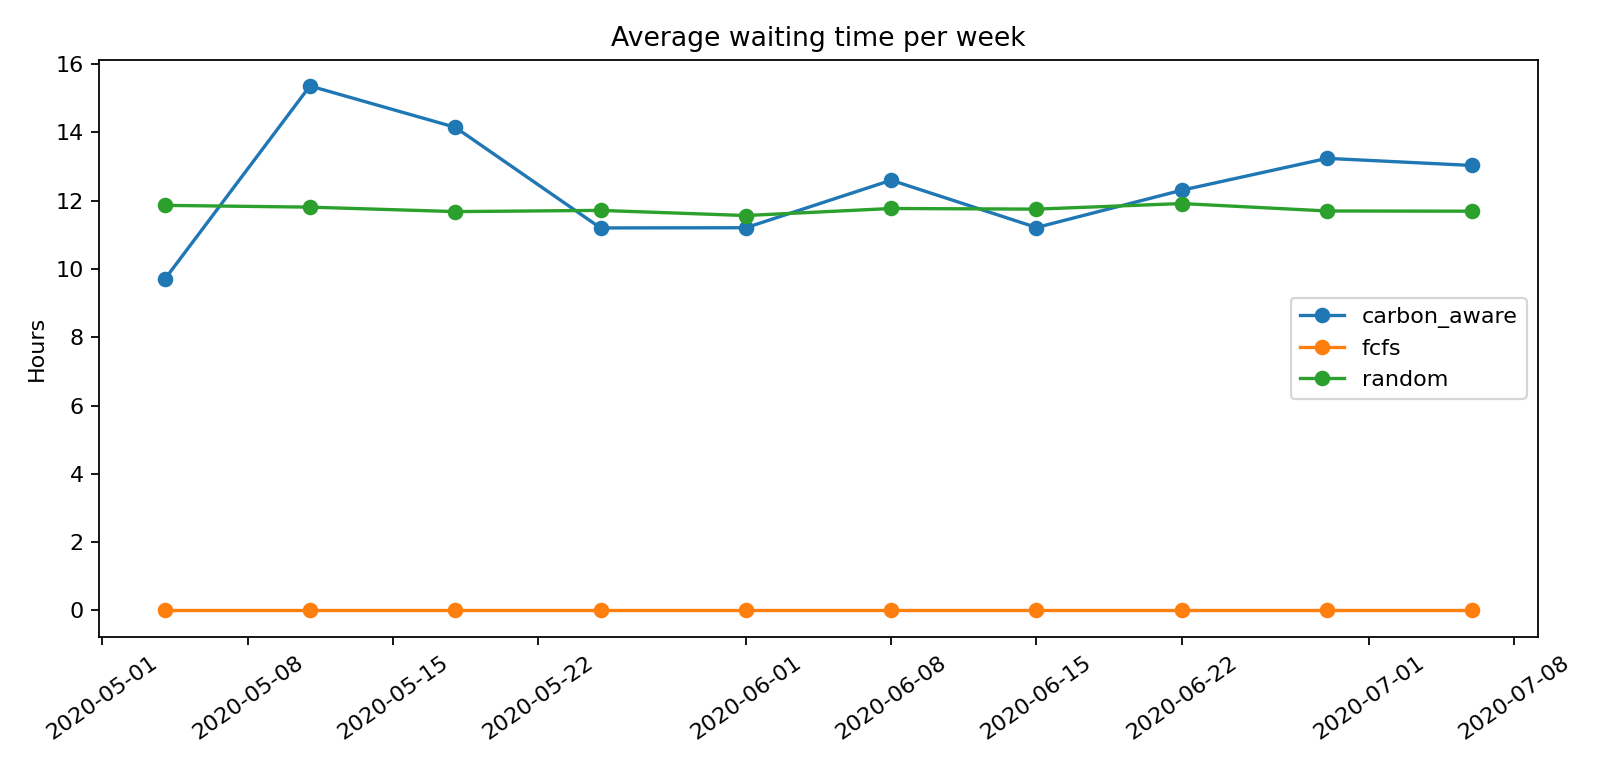

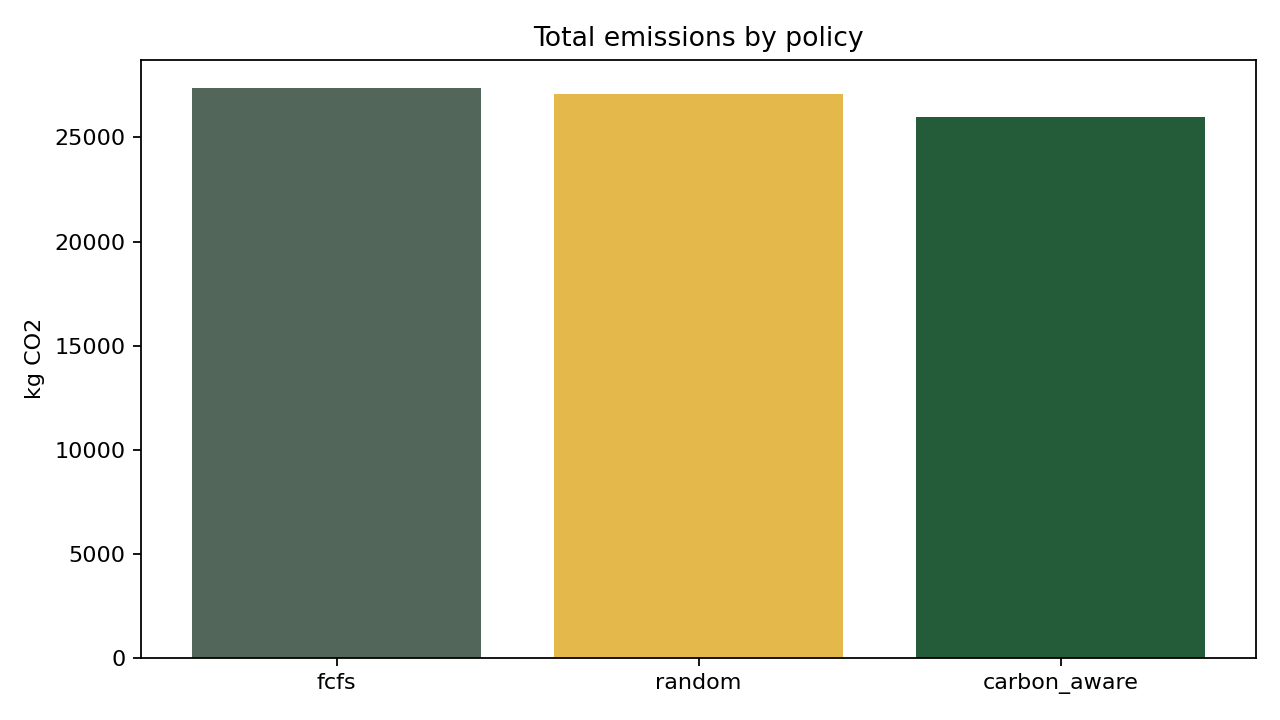

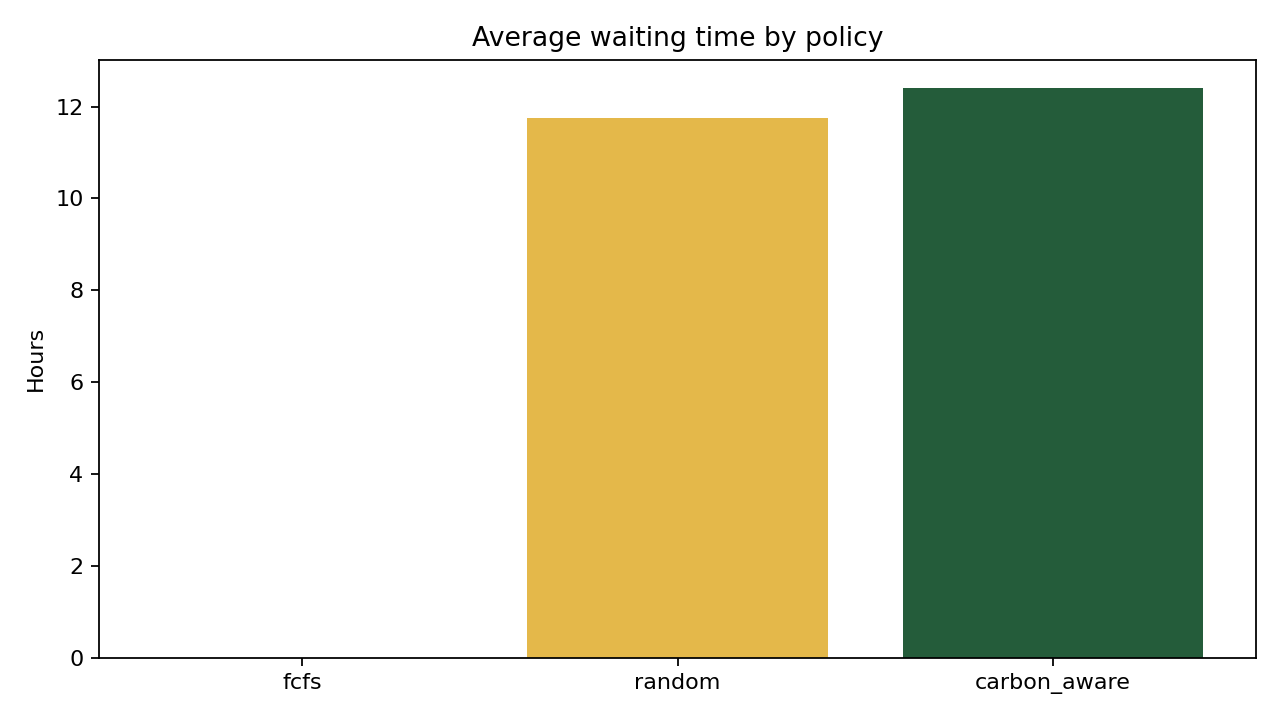

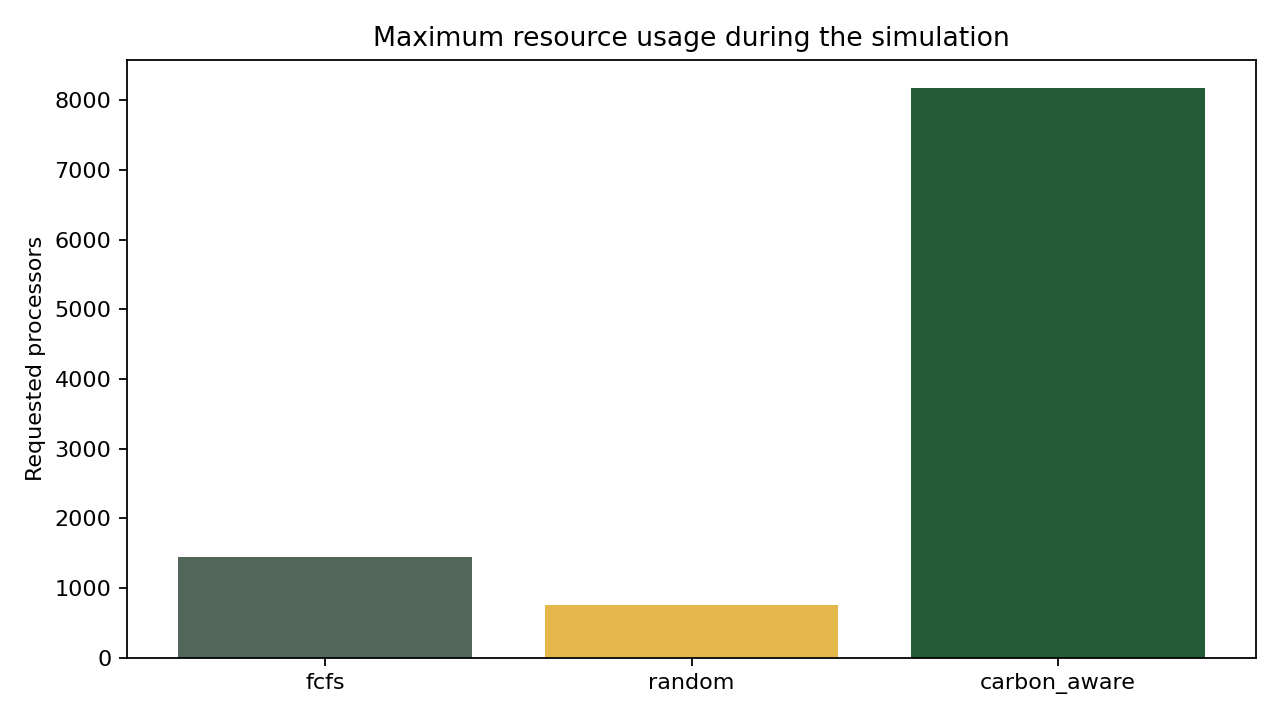

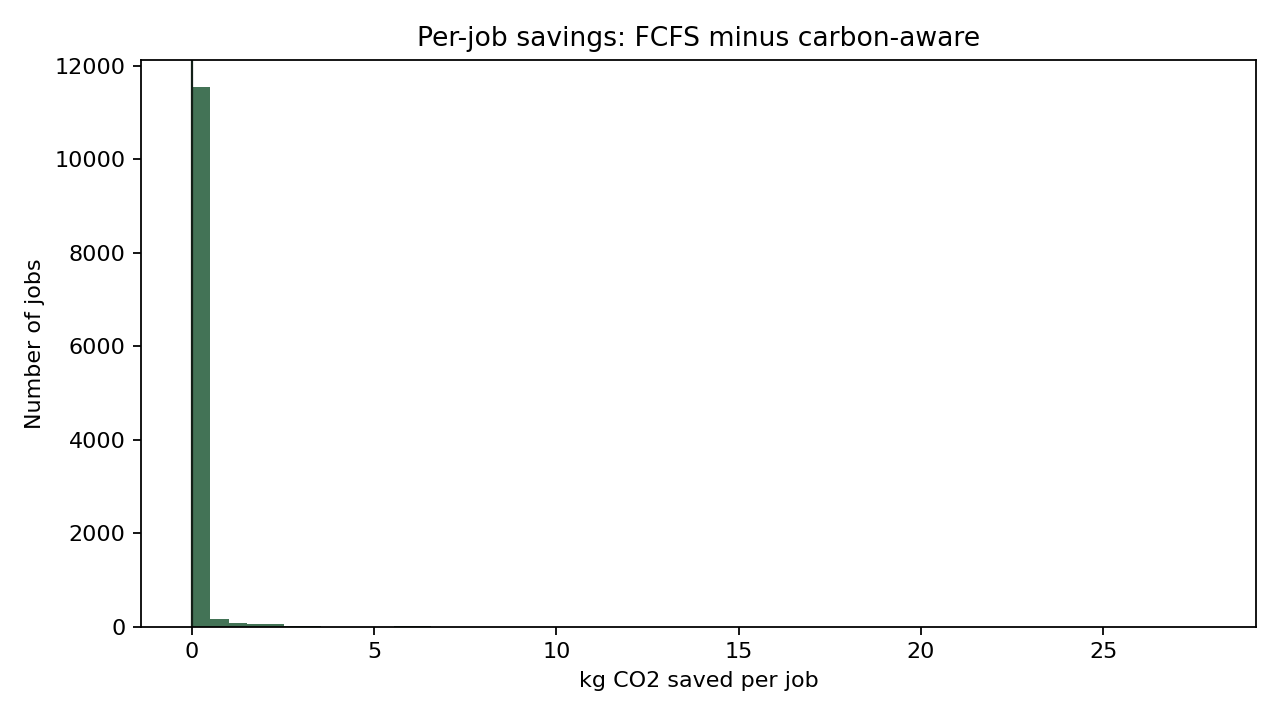

In [4]:
for name in [
    'synthetic_carbon_curve_week.png',
    'scheduler_weekly_emissions.png',
    'scheduler_weekly_reduction_pct.png',
    'scheduler_weekly_energy.png',
    'scheduler_weekly_avg_carbon.png',
    'scheduler_weekly_wait.png',
    'scheduler_emissions_comparison.png',
    'scheduler_wait_comparison.png',
    'scheduler_nodes_usage.png',
    'scheduler_per_job_savings_histogram.png',
]:
    display(Image(filename=str(RESULTS / name)))

## Skipped Job Check

In the earlier prototype, many jobs were skipped because the model was too simplified. Here, skipped jobs are reported explicitly by policy and reason.

In [5]:
skipped = pd.read_csv(RESULTS / 'skipped_jobs.csv')
if skipped.empty:
    print('No skipped jobs.')
else:
    display(skipped.groupby(['policy', 'reason']).size().reset_index(name='count'))

No skipped jobs.


## Schedule Example

In [6]:
schedule = pd.read_csv(RESULTS / 'schedules.csv')
cols = ['policy', 'job_id', 'submit_time', 'scheduled_start', 'scheduled_end', 'req_nodes', 'wait_h', 'actual_emissions_kg']
schedule[cols].head(20)

,policy,job_id,submit_time,scheduled_start,scheduled_end,req_nodes,wait_h,actual_emissions_kg
0,fcfs,5370710,2020-05-06 06:41:32+00:00,2020-05-06 06:30:00+00:00,2020-05-06 10:30:00+00:00,1,0.0,0.685859
1,fcfs,175694,2020-05-06 06:48:37+00:00,2020-05-06 06:30:00+00:00,2020-05-06 12:00:00+00:00,8,0.0,8.742559
2,fcfs,2214444,2020-05-06 07:04:53+00:00,2020-05-06 07:00:00+00:00,2020-05-06 12:00:00+00:00,13,0.0,7.950694
3,fcfs,2687047,2020-05-06 07:45:12+00:00,2020-05-06 07:30:00+00:00,2020-05-06 13:30:00+00:00,16,0.0,17.711482
4,fcfs,4281751,2020-05-06 07:59:15+00:00,2020-05-06 07:30:00+00:00,2020-05-06 10:00:00+00:00,9,0.0,2.906611
5,fcfs,584948,2020-05-06 08:04:51+00:00,2020-05-06 08:00:00+00:00,2020-05-06 10:00:00+00:00,4,0.0,0.991773
6,fcfs,3192383,2020-05-06 08:12:32+00:00,2020-05-06 08:00:00+00:00,2020-05-06 12:00:00+00:00,1,0.0,0.733017
7,fcfs,3783714,2020-05-06 08:23:13+00:00,2020-05-06 08:00:00+00:00,2020-05-06 18:30:00+00:00,13,0.0,16.668413
8,fcfs,3096661,2020-05-06 08:31:39+00:00,2020-05-06 08:30:00+00:00,2020-05-06 11:00:00+00:00,6,0.0,1.965195
9,fcfs,4678367,2020-05-06 08:43:38+00:00,2020-05-06 08:30:00+00:00,2020-05-06 11:30:00+00:00,1,0.0,0.453507


## Key Message

The carbon-aware scheduler introduces a trade-off: it reduces emissions by choosing lower-carbon-intensity windows, but it increases waiting time. The strongest part of the final run is that the improvement is not measured on one repeated week: the comparison covers 10 real weeks and shows both the average effect and weekly variability.